# E-Commerce Sales Analysis  
*By Maria Ilnitska | Portfolio Project*

1. **Business Problem**

An e-commerce company operating in Turkey wants to:

- Increase revenue

- Improve customer retention

- Optimize marketing efforts

- Improve delivery performance

Management needs data-driven insights to guide strategic decisions.

2. **Project Objectives**

This analysis aims to:

- Identify revenue trends and seasonality

- Analyze product category performance

- Segment customers based on behavior

- Evaluate delivery impact on satisfaction

- Provide actionable business recommendations

3. **Data Loading**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10,6)

In [10]:
df = pd.read_csv("../data/ecommerce_customer_behavior_dataset.csv")
df.head()

,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


4. **Data Overwiew**

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Order_ID                  5000 non-null   str    
 1   Customer_ID               5000 non-null   str    
 2   Date                      5000 non-null   str    
 3   Age                       5000 non-null   int64  
 4   Gender                    5000 non-null   str    
 5   City                      5000 non-null   str    
 6   Product_Category          5000 non-null   str    
 7   Unit_Price                5000 non-null   float64
 8   Quantity                  5000 non-null   int64  
 9   Discount_Amount           5000 non-null   float64
 10  Total_Amount              5000 non-null   float64
 11  Payment_Method            5000 non-null   str    
 12  Device_Type               5000 non-null   str    
 13  Session_Duration_Minutes  5000 non-null   int64  
 14  Pages_Viewed       

In [12]:
df.describe()

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000
mean,35.032600,455.834120,2.220000,24.852804,983.108914,14.57340,8.98420,6.497000,3.902800
std,11.080546,712.477209,1.398711,88.385124,1898.978528,8.66575,2.80434,3.464966,1.128542
min,18.000000,5.180000,1.000000,0.000000,7.870000,1.00000,1.00000,1.000000,1.000000
25%,27.000000,76.587500,1.000000,0.000000,122.517500,8.00000,7.00000,4.000000,3.000000
50%,35.000000,182.950000,2.000000,0.000000,337.910000,13.00000,9.00000,6.000000,4.000000
75%,42.000000,513.930000,3.000000,8.760000,979.695000,19.00000,11.00000,8.000000,5.000000
max,75.000000,7159.450000,5.000000,1525.550000,22023.900000,73.00000,24.00000,25.000000,5.000000


In [13]:
df.isnull().sum()

Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
dtype: int64

The dataset contains 5,000 transactions from January 2023 to March 2024.
There are no missing values and data types are consistent.

5. **Data Preparation**

In [15]:
df["Date"] = pd.to_datetime(df["Date"])

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Year_Month"] = df["Date"].dt.to_period("M")

In [16]:
df["Revenue_Check"] = df["Unit_Price"] * df["Quantity"] - df["Discount_Amount"]

A revenue check column was created to validate the Total_Amount consistency.

6. **Sales Trend Analysis**
- Monthly Revenue

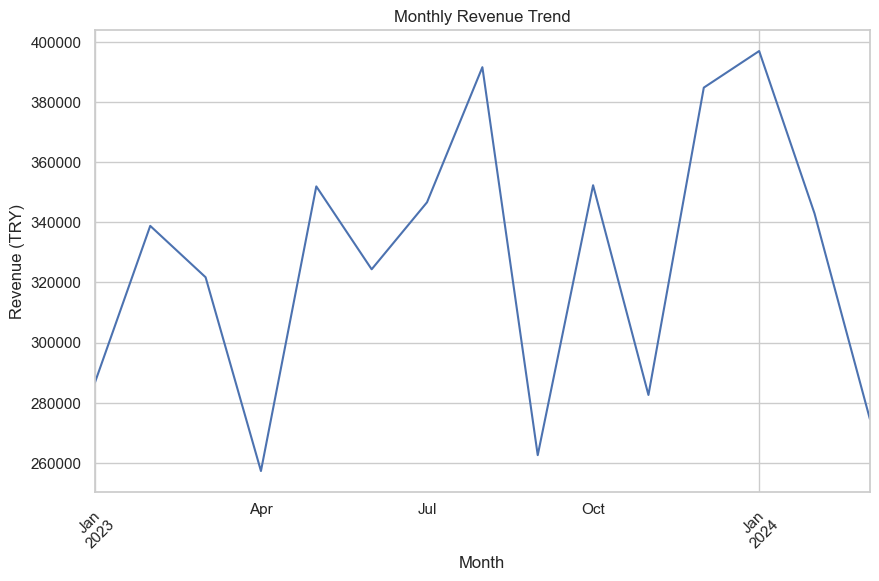

In [17]:
monthly_revenue = df.groupby("Year_Month")["Total_Amount"].sum()

monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (TRY)")
plt.xticks(rotation=45)
plt.show()

Revenue shows seasonal peaks, particularly in Q4, likely influenced by promotional periods and holiday shopping behavior.

7. **Product Category Performance**

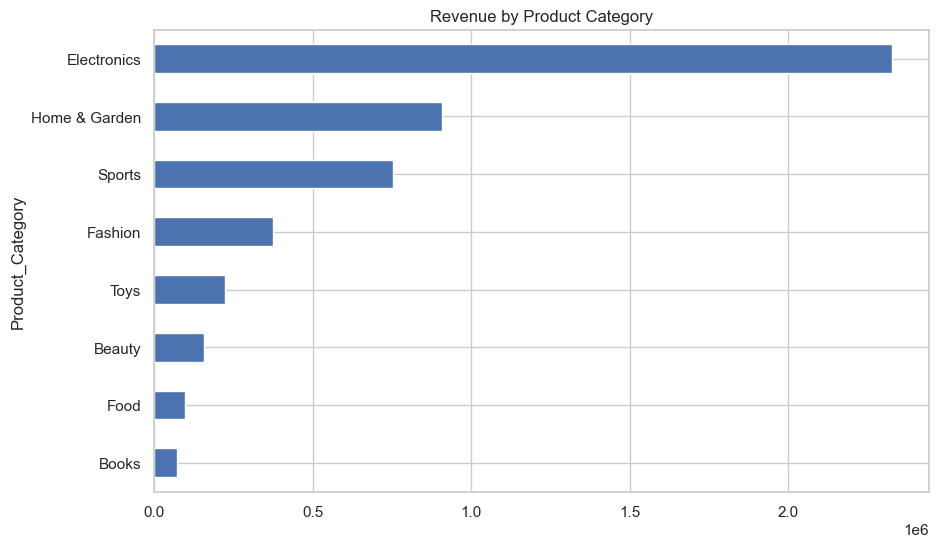

In [18]:
category_revenue = df.groupby("Product_Category")["Total_Amount"].sum().sort_values()

category_revenue.plot(kind="barh")
plt.title("Revenue by Product Category")
plt.show()

Electronics and Fashion categories generate the highest total revenue, indicating strong customer demand in these segments.

8. **Customer Analysis**
- Returning vs New Customers

In [19]:
df["Is_Returning_Customer"].value_counts(normalize=True) * 100

Is_Returning_Customer
True     59.8
False    40.2
Name: proportion, dtype: float64

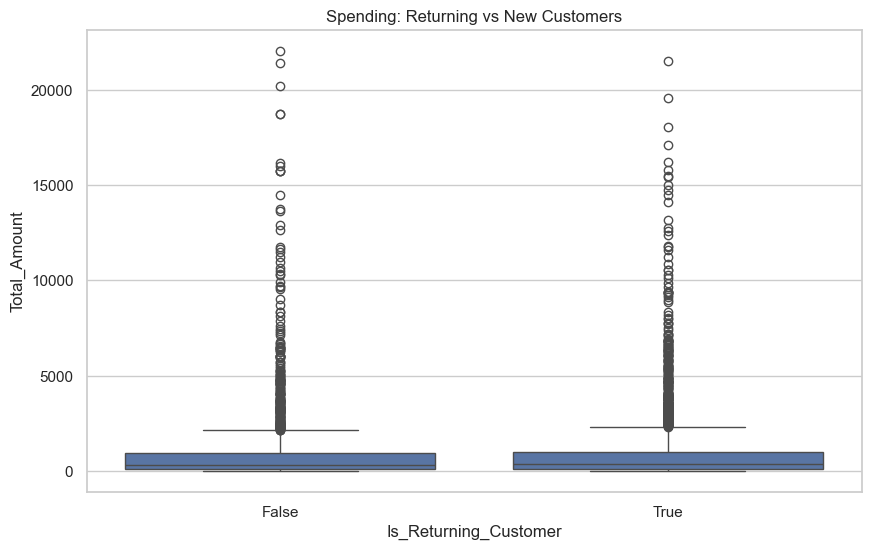

In [20]:
sns.boxplot(x="Is_Returning_Customer", y="Total_Amount", data=df)
plt.title("Spending: Returning vs New Customers")
plt.show()

Returning customers tend to have higher average order values, suggesting retention is a key revenue driver.

9. **Customer Segmentation (RFM + KMeans)**

In [21]:
snapshot_date = df["Date"].max() + pd.Timedelta(days=1)

rfm = df.groupby("Customer_ID").agg({
    "Date": lambda x: (snapshot_date - x.max()).days,
    "Order_ID": "count",
    "Total_Amount": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]
rfm.head()

,Recency,Frequency,Monetary
Customer_ID,,,
CUST_00001,124,1,219.32
CUST_00002,394,1,332.34
CUST_00003,439,1,66.44
CUST_00004,72,1,112.65
CUST_00005,311,1,349.45


- Normalize & Cluster

In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

kmeans = KMeans(n_clusters=4, random_state=42)
rfm["Cluster"] = kmeans.fit_predict(rfm_scaled)

rfm.groupby("Cluster").mean()

,Recency,Frequency,Monetary
Cluster,,,
0,337.528120,1.0,531.242540
1,112.121983,1.0,520.104664
2,224.393939,1.0,12919.100455
3,209.810026,1.0,4402.262243


Cluster 0 represents high-value customers with high frequency and spending.
Cluster 2 appears to contain low-engagement customers with low monetary contribution.

10. **Device Behavior Analysis**

In [23]:
df.groupby("Device_Type")[["Total_Amount", "Session_Duration_Minutes"]].mean()

,Total_Amount,Session_Duration_Minutes
Device_Type,,
Desktop,964.408989,14.922852
Mobile,1005.534397,14.348837
Tablet,920.996255,14.633603


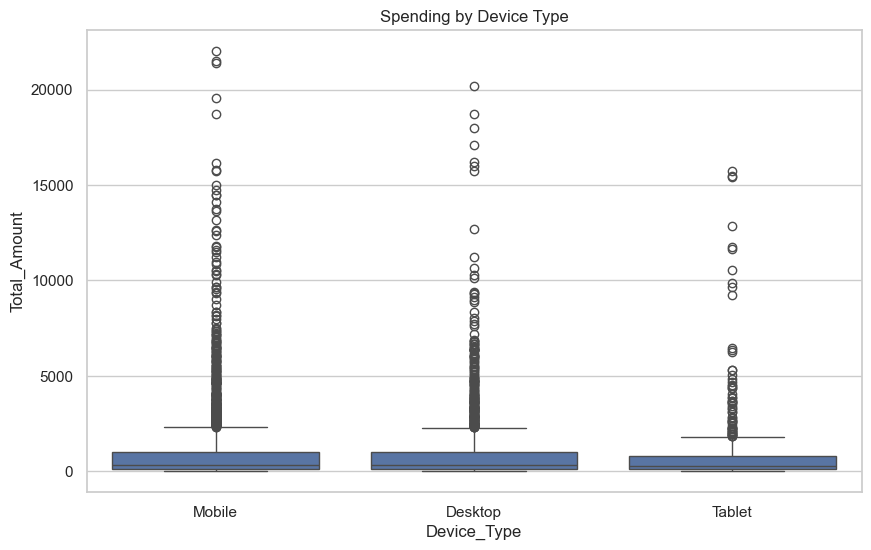

In [24]:
sns.boxplot(x="Device_Type", y="Total_Amount", data=df)
plt.title("Spending by Device Type")
plt.show()

Desktop users demonstrate higher average transaction values compared to mobile users, despite mobile generating more sessions.

11. **Delivery & Customer Satisfaction**

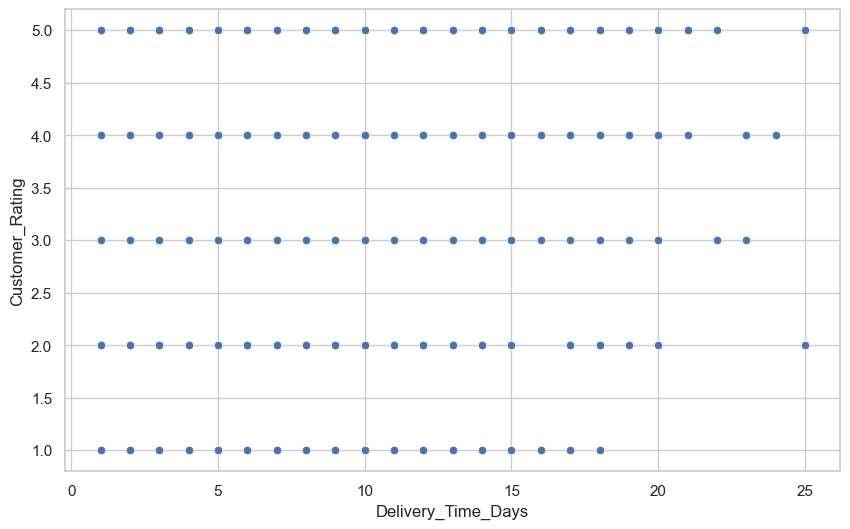

In [25]:
sns.scatterplot(
    x="Delivery_Time_Days",
    y="Customer_Rating",
    data=df
)
plt.show()

There is a negative relationship between delivery time and customer rating. Longer delivery times correlate with lower satisfaction scores.

## Business Recommendations

**Marketing**

Focus retention campaigns on high-value clusters

Personalize offers for mid-tier customers

**Operations**

Reduce delivery times in cities with lower ratings

Optimize logistics during peak seasonal months

**Product Strategy**

Increase inventory for top-performing categories

Bundle low-performing categories with best sellers